# Train YOLO26n Human Detector From Full Roboflow Export

This notebook trains a one-class human detector from:

`data/labeled/human_detection`

The Roboflow export currently has only a `train` split and mixed label rows:
standard YOLO boxes plus polygon-style rows. The first part converts every
label to standard YOLO boxes and creates a grouped train/val/test split before
training.


## Training Choice

Default settings are tuned for training on a Mac M4 with MPS, with CUDA as
fallback if the notebook is run on a GPU workstation. CPU remains a last-resort
fallback, but it will be much slower:

- model: `yolo26n.pt`
- image size: `320`
- batch: `16` on MPS/CUDA, `8` on CPU
- epochs: `220`
- patience: `45`
- grouped split by original frame stem to reduce leakage from Roboflow variants
- moderate training augmentation only; no offline dataset expansion

The model is still `yolo26n.pt` so inference remains lightweight. If recall is
too low after a full run, the next controlled experiment should be `IMG_SIZE =
384` before switching to a larger YOLO checkpoint.


In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import random
import shutil
import time

import cv2
import matplotlib.pyplot as plt
import torch

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

SOURCE_DATASET = PROJECT_ROOT / "data" / "labeled" / "human_detection"
SOURCE_IMAGES = SOURCE_DATASET / "train" / "images"
SOURCE_LABELS = SOURCE_DATASET / "train" / "labels"

PREPARED_DATASET = PROJECT_ROOT / "data" / "processed" / "human_detection_yolo26_full_boxes_split"
DATA_YAML = PREPARED_DATASET / "data.yaml"
RUNS_DIR = PROJECT_ROOT / "runs" / "yolo26"
LOCAL_PRETRAINED_WEIGHTS = PROJECT_ROOT / "notebooks" / "yolo26n.pt"
PRETRAINED_WEIGHTS = LOCAL_PRETRAINED_WEIGHTS if LOCAL_PRETRAINED_WEIGHTS.exists() else "yolo26n.pt"

TRAIN_NAME = "yolo26n_human_detection_full_roboflow_accelerated_img320"
SPLITS = ["train", "val", "test"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SEED = 42

def select_yolo_device():
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    if torch.cuda.is_available():
        return 0
    return "cpu"

TRAIN_DEVICE = select_yolo_device()
TRAIN_WORKERS = 4 if TRAIN_DEVICE != "cpu" else 0
TRAIN_BATCH = 16 if TRAIN_DEVICE != "cpu" else 8

print("Project root:", PROJECT_ROOT)
print("Source dataset:", SOURCE_DATASET)
print("Prepared dataset:", PREPARED_DATASET)
print("Start weights:", PRETRAINED_WEIGHTS)
print("Run output:", RUNS_DIR / TRAIN_NAME)
print("Training device:", TRAIN_DEVICE)
print("Training batch:", TRAIN_BATCH)
print("Training workers:", TRAIN_WORKERS)

if not SOURCE_IMAGES.exists() or not SOURCE_LABELS.exists():
    raise FileNotFoundError("Expected Roboflow export at data/labeled/human_detection/train/images and train/labels")


Project root: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection
Source dataset: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/labeled/human_detection
Prepared dataset: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/processed/human_detection_yolo26_full_boxes_split
Start weights: yolo26n.pt
Run output: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/runs/yolo26/yolo26n_human_detection_full_roboflow_accelerated_img320
Training device: mps
Training batch: 16
Training workers: 4


## Convert Mixed Labels And Build Split

The source export contains polygon rows. This conversion keeps class `0 = Human`
and converts each polygon into the tight normalized box around the polygon
points. Empty labels are kept as background images.


In [2]:
def original_group_key(image_path: Path) -> str:
    # Roboflow variants look like img_000001_jpg.rf.<hash>.jpg.
    # Splitting by the prefix keeps variants of the same source frame together.
    return image_path.stem.split(".rf.", 1)[0]


def clamp01(value: float) -> float:
    return max(0.0, min(1.0, value))


def row_to_box(parts):
    class_id = int(float(parts[0]))
    values = [float(v) for v in parts[1:]]
    if class_id != 0:
        raise ValueError(f"Unexpected class id {class_id}; expected only 0 = human")

    if len(parts) == 5:
        xc, yc, w, h = values
        x1 = clamp01(xc - w / 2)
        y1 = clamp01(yc - h / 2)
        x2 = clamp01(xc + w / 2)
        y2 = clamp01(yc + h / 2)
        source_type = "box"
    elif len(values) >= 6 and len(values) % 2 == 0:
        xs = values[0::2]
        ys = values[1::2]
        x1, x2 = clamp01(min(xs)), clamp01(max(xs))
        y1, y2 = clamp01(min(ys)), clamp01(max(ys))
        source_type = "polygon"
    else:
        raise ValueError(f"Bad YOLO row length: {len(parts)} fields")

    w = x2 - x1
    h = y2 - y1
    if w <= 0 or h <= 0:
        return None, source_type
    xc = x1 + w / 2
    yc = y1 + h / 2
    return (0, xc, yc, w, h), source_type


def read_and_convert_label(label_path: Path):
    converted = []
    counts = Counter()
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        counts["empty_labels"] += 1
        return converted, counts

    for line in text.splitlines():
        parts = line.split()
        box, source_type = row_to_box(parts)
        counts[f"{source_type}_rows"] += 1
        if box is None:
            counts["dropped_zero_area"] += 1
            continue
        converted.append(box)
    return converted, counts


def write_yolo_box_label(path: Path, boxes):
    rows = [f"{cls} {xc:.8f} {yc:.8f} {w:.8f} {h:.8f}" for cls, xc, yc, w, h in boxes]
    path.write_text("\n".join(rows) + ("\n" if rows else ""), encoding="utf-8")


def split_groups(groups, train_ratio=0.70, val_ratio=0.20, seed=SEED):
    keys = sorted(groups)
    random.Random(seed).shuffle(keys)
    train_end = int(len(keys) * train_ratio)
    val_end = train_end + int(len(keys) * val_ratio)
    split_by_key = {}
    for key in keys[:train_end]:
        split_by_key[key] = "train"
    for key in keys[train_end:val_end]:
        split_by_key[key] = "val"
    for key in keys[val_end:]:
        split_by_key[key] = "test"
    return split_by_key


images = [p for p in sorted(SOURCE_IMAGES.iterdir()) if p.suffix.lower() in IMAGE_EXTS]
if not images:
    raise RuntimeError(f"No images found in {SOURCE_IMAGES}")

missing_labels = [p.name for p in images if not (SOURCE_LABELS / f"{p.stem}.txt").exists()]
if missing_labels:
    raise RuntimeError(f"Images without labels: {len(missing_labels)}")

groups = defaultdict(list)
for image_path in images:
    groups[original_group_key(image_path)].append(image_path)

split_by_key = split_groups(groups)

if PREPARED_DATASET.exists():
    shutil.rmtree(PREPARED_DATASET)
for split in SPLITS:
    (PREPARED_DATASET / "images" / split).mkdir(parents=True, exist_ok=True)
    (PREPARED_DATASET / "labels" / split).mkdir(parents=True, exist_ok=True)

stats = Counter()
split_stats = Counter()

for image_path in images:
    split = split_by_key[original_group_key(image_path)]
    label_path = SOURCE_LABELS / f"{image_path.stem}.txt"
    boxes, label_stats = read_and_convert_label(label_path)
    stats.update(label_stats)
    stats["images"] += 1
    stats["boxes"] += len(boxes)
    split_stats[f"{split}_images"] += 1
    split_stats[f"{split}_boxes"] += len(boxes)

    shutil.copy2(image_path, PREPARED_DATASET / "images" / split / image_path.name)
    write_yolo_box_label(PREPARED_DATASET / "labels" / split / f"{image_path.stem}.txt", boxes)

DATA_YAML.write_text(
    "path: " + PREPARED_DATASET.as_posix() + "\n"
    "train: images/train\n"
    "val: images/val\n"
    "test: images/test\n"
    "nc: 1\n"
    "names:\n"
    "- Human\n",
    encoding="utf-8",
)

print("Prepared dataset:", PREPARED_DATASET)
print("Data YAML:", DATA_YAML)
print("Overall stats:", dict(stats))
print("Split stats:", dict(split_stats))
print("Groups:", len(groups))


Prepared dataset: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/processed/human_detection_yolo26_full_boxes_split
Data YAML: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/processed/human_detection_yolo26_full_boxes_split/data.yaml
Overall stats: {'box_rows': 1002, 'images': 1356, 'boxes': 2257, 'polygon_rows': 1255, 'empty_labels': 46}
Split stats: {'train_images': 944, 'train_boxes': 1564, 'test_images': 150, 'test_boxes': 247, 'val_images': 262, 'val_boxes': 446}
Groups: 328


## Dataset Sanity Check


In [3]:
def read_yolo_box_label(path: Path):
    rows = []
    text = path.read_text(encoding="utf-8").strip()
    if not text:
        return rows
    for line_no, line in enumerate(text.splitlines(), 1):
        parts = line.split()
        if len(parts) != 5:
            raise ValueError(f"Bad converted row in {path}:{line_no}: {line!r}")
        class_id = int(parts[0])
        values = tuple(float(v) for v in parts[1:])
        if class_id != 0 or any(v < 0 or v > 1 for v in values):
            raise ValueError(f"Invalid converted row in {path}:{line_no}: {line!r}")
        if values[2] <= 0 or values[3] <= 0:
            raise ValueError(f"Zero-area converted row in {path}:{line_no}: {line!r}")
        rows.append((class_id, *values))
    return rows


summary = []
image_sizes = Counter()
box_areas = []
empty_labels = 0

for split in SPLITS:
    image_dir = PREPARED_DATASET / "images" / split
    label_dir = PREPARED_DATASET / "labels" / split
    split_images = [p for p in sorted(image_dir.iterdir()) if p.suffix.lower() in IMAGE_EXTS]
    split_labels = sorted(label_dir.glob("*.txt"))
    image_stems = {p.stem for p in split_images}
    label_stems = {p.stem for p in split_labels}
    missing_labels = image_stems - label_stems
    missing_images = label_stems - image_stems
    if missing_labels or missing_images:
        raise RuntimeError(f"{split}: missing_labels={len(missing_labels)}, missing_images={len(missing_images)}")

    boxes = 0
    for image_path in split_images:
        image = cv2.imread(str(image_path))
        if image is None:
            raise ValueError(f"Could not read image: {image_path}")
        h, w = image.shape[:2]
        image_sizes[(w, h)] += 1
        rows = read_yolo_box_label(label_dir / f"{image_path.stem}.txt")
        if not rows:
            empty_labels += 1
        boxes += len(rows)
        for _, _, _, bw, bh in rows:
            box_areas.append(bw * bh)
    summary.append({"split": split, "images": len(split_images), "labels": len(split_labels), "boxes": boxes})

for row in summary:
    print(row)
print("Image sizes:", image_sizes.most_common())
print("Empty/background labels:", empty_labels)
if box_areas:
    sorted_areas = sorted(box_areas)
    print("Box area min/median/max:", sorted_areas[0], sorted_areas[len(sorted_areas)//2], sorted_areas[-1])


{'split': 'train', 'images': 944, 'labels': 944, 'boxes': 1564}
{'split': 'val', 'images': 262, 'labels': 262, 'boxes': 446}
{'split': 'test', 'images': 150, 'labels': 150, 'boxes': 247}
Image sizes: [((512, 512), 1356)]
Empty/background labels: 46
Box area min/median/max: 0.001296996875 0.049133301875 1.0


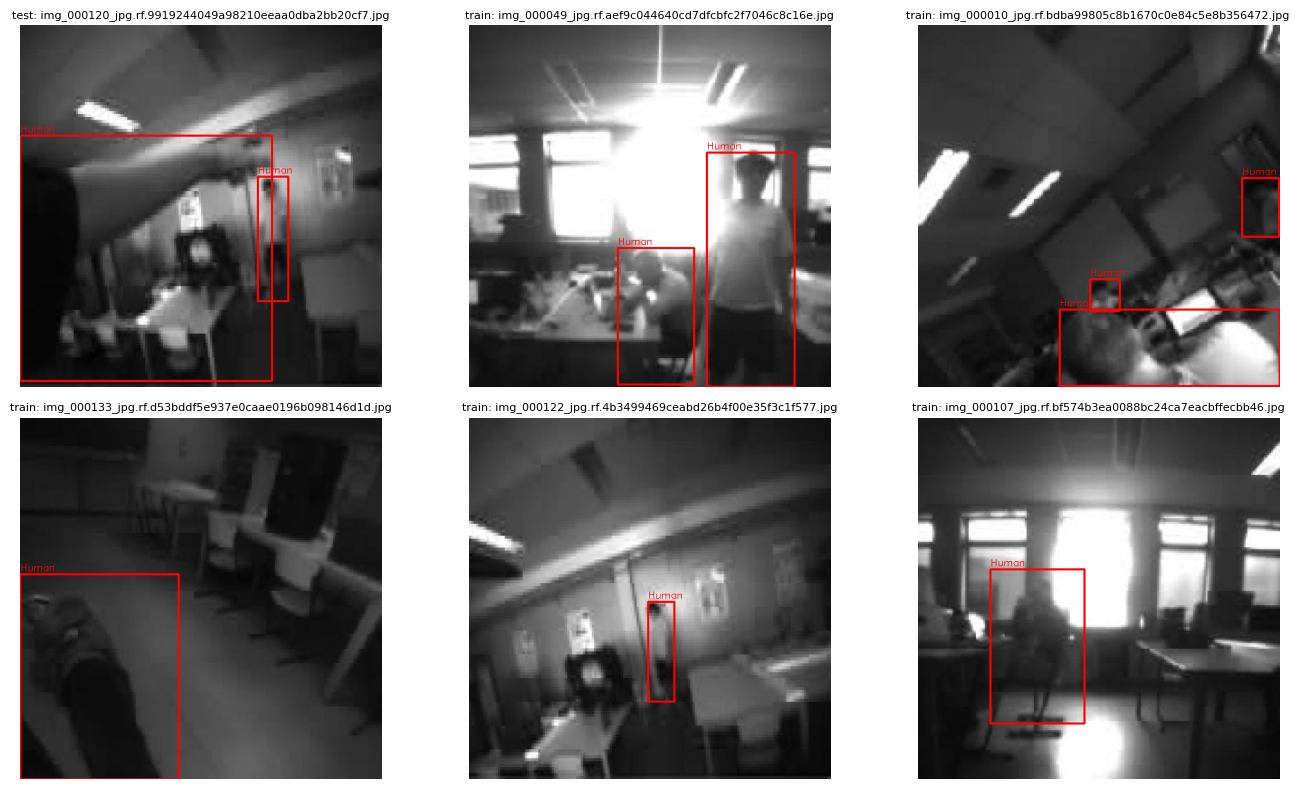

In [4]:
def draw_yolo_boxes(image_path: Path, label_path: Path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    for _, xc, yc, bw, bh in read_yolo_box_label(label_path):
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(image, "Human", (x1, max(y1 - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)
    return image


pairs = []
for split in SPLITS:
    for image_path in sorted((PREPARED_DATASET / "images" / split).iterdir()):
        if image_path.suffix.lower() in IMAGE_EXTS:
            pairs.append((split, image_path, PREPARED_DATASET / "labels" / split / f"{image_path.stem}.txt"))

sample = random.Random(SEED).sample(pairs, k=min(6, len(pairs)))
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (split, image_path, label_path) in zip(axes.ravel(), sample):
    ax.imshow(draw_yolo_boxes(image_path, label_path))
    ax.set_title(f"{split}: {image_path.name}", fontsize=8)
    ax.axis("off")
plt.tight_layout()


## Train From Pretrained YOLO26n

Run the next cell only when you are ready to train. It writes checkpoints under
`runs/yolo26/yolo26n_human_detection_full_roboflow_accelerated_img320`.


In [5]:
IMG_SIZE = 320

TRAIN_ARGS = {
    "data": str(DATA_YAML),
    "epochs": 220,
    "imgsz": IMG_SIZE,
    "batch": TRAIN_BATCH,
    "patience": 55,
    "workers": TRAIN_WORKERS,
    "device": TRAIN_DEVICE,
    "cache": True,
    "optimizer": "auto",
    "lr0": 0.004,
    "lrf": 0.01,
    "warmup_epochs": 3.0,
    "cos_lr": True,
    "close_mosaic": 25,
    "mosaic": 0.65,
    "scale": 0.45,
    "translate": 0.10,
    "degrees": 3.0,
    "shear": 0.0,
    "perspective": 0.0,
    "flipud": 0.0,
    "fliplr": 0.5,
    "hsv_h": 0.0,
    "hsv_s": 0.05,
    "hsv_v": 0.35,
    "mixup": 0.0,
    "copy_paste": 0.0,
    "project": str(RUNS_DIR),
    "name": TRAIN_NAME,
    "exist_ok": True,
    "seed": SEED,
    "deterministic": True,
    "plots": True,
    "val": True,
    "save": True,
    "save_period": 20,
}

print("Weights:", PRETRAINED_WEIGHTS)
print("Output:", RUNS_DIR / TRAIN_NAME)
for key, value in TRAIN_ARGS.items():
    print(f"{key}: {value}")


Weights: yolo26n.pt
Output: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/runs/yolo26/yolo26n_human_detection_full_roboflow_accelerated_img320
data: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/processed/human_detection_yolo26_full_boxes_split/data.yaml
epochs: 220
imgsz: 320
batch: 16
patience: 55
workers: 4
device: mps
cache: True
optimizer: auto
lr0: 0.004
lrf: 0.01
warmup_epochs: 3.0
cos_lr: True
close_mosaic: 25
mosaic: 0.65
scale: 0.45
translate: 0.1
degrees: 3.0
shear: 0.0
perspective: 0.0
flipud: 0.0
fliplr: 0.5
hsv_h: 0.0
hsv_s: 0.05
hsv_v: 0.35
mixup: 0.0
copy_paste: 0.0
project: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/runs/yolo26
name: yolo26n_human_detection_full_roboflow_accelerated_img320
exist_ok: True
seed: 42
deterministic: True
plots: True
val: True
save: True
save_period: 20


In [6]:
from ultralytics import YOLO

model = YOLO(str(PRETRAINED_WEIGHTS))
results = model.train(**TRAIN_ARGS)


Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.12.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=25, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/processed/human_detection_yolo26_full_boxes_split/data.yaml, degrees=3.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=220, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.05, hsv_v=0.35, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.004, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.65, multi_scale=0.0, name=yolo26n_human_detection

## Evaluate Best Checkpoint On Test Split


In [7]:
from ultralytics import YOLO

best_weights = RUNS_DIR / TRAIN_NAME / "weights" / "best.pt"
print("Best weights:", best_weights)

best_model = YOLO(str(best_weights))
test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=TRAIN_ARGS["imgsz"],
    device=TRAIN_DEVICE,
    workers=TRAIN_WORKERS,
    plots=True,
)
print(test_metrics)


Best weights: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/runs/yolo26/yolo26n_human_detection_full_roboflow_accelerated_img320/weights/best.pt
Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.12.0 MPS (Apple M4)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 38.5±21.1 MB/s, size: 14.2 KB)
val: Scanning /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/processed/human_detection_yolo26_full_boxes_split/labels/test... 150 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 5.0Kit/s 0.0s
val: New cache created: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/processed/human_detection_yolo26_full_boxes_split/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 5.6it/s 1.8s.1ss
                   all        150        247      0.936      0.828      0.904      0.595
Sp

## Compare Pretrained Baseline Versus Retrained Model


In [8]:
from ultralytics import YOLO

models_to_compare = {
    "pretrained_yolo26n": "yolo26n.pt",
    "full_roboflow_retrained": str(best_weights),
}

comparison_rows = []
for name, weights in models_to_compare.items():
    print(f"Validating {name}...")
    model = YOLO(weights)
    metrics = model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=TRAIN_ARGS["imgsz"],
        device=TRAIN_DEVICE,
        workers=TRAIN_WORKERS,
        plots=False,
        verbose=False,
    )
    comparison_rows.append(
        {
            "model": name,
            "precision": float(metrics.box.mp),
            "recall": float(metrics.box.mr),
            "mAP50": float(metrics.box.map50),
            "mAP50-95": float(metrics.box.map),
            "inference_ms": float(metrics.speed.get("inference", 0.0)),
        }
    )

for row in comparison_rows:
    print(row)


Validating pretrained_yolo26n...
Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.12.0 MPS (Apple M4)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 674.1±203.7 MB/s, size: 13.1 KB)
val: Scanning /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/processed/human_detection_yolo26_full_boxes_split/labels/test.cache... 150 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 78.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 7.9it/s 1.3s.1s
                   all        150        247      0.563        0.3      0.368      0.218
Speed: 0.1ms preprocess, 3.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Validating full_roboflow_retrained...
Ultralytics 8.4.60 🚀 Python-3.10.20 torch-2.12.0 MPS (Apple M4)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image ac

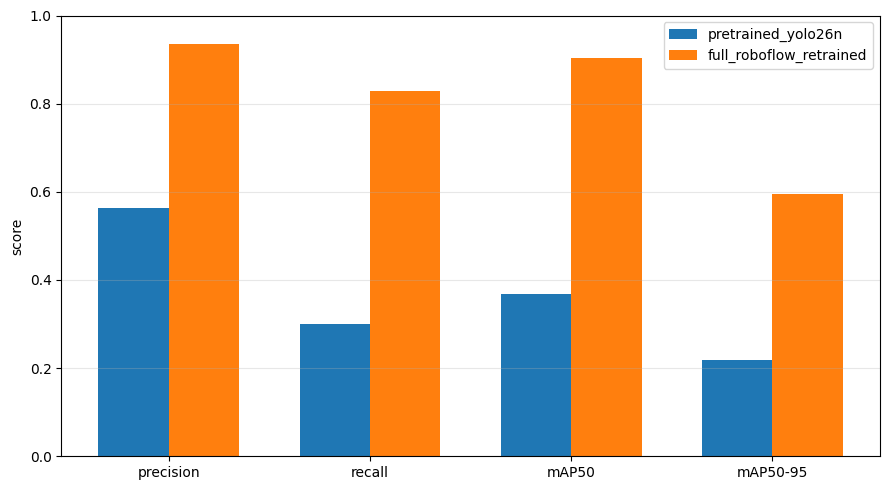

In [9]:
metric_names = ["precision", "recall", "mAP50", "mAP50-95"]
labels = [row["model"] for row in comparison_rows]

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(metric_names))
width = 0.35
for i, row in enumerate(comparison_rows):
    offsets = [v + (i - 0.5) * width for v in x]
    ax.bar(offsets, [row[m] for m in metric_names], width=width, label=row["model"])
ax.set_xticks(list(x))
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()


## Single-Image Timing On Selected Device


In [10]:
def time_single_image(model, image_path: Path, imgsz: int, repeats: int = 30):
    model.predict(source=str(image_path), imgsz=imgsz, device=TRAIN_DEVICE, verbose=False)
    start = time.perf_counter()
    for _ in range(repeats):
        model.predict(source=str(image_path), imgsz=imgsz, device=TRAIN_DEVICE, verbose=False)
    elapsed = time.perf_counter() - start
    return elapsed * 1000 / repeats


test_images = [p for p in sorted((PREPARED_DATASET / "images" / "test").iterdir()) if p.suffix.lower() in IMAGE_EXTS]
image_path = test_images[0]
new_model = YOLO(str(best_weights))
ms = time_single_image(new_model, image_path, TRAIN_ARGS["imgsz"])
print("Image:", image_path)
print(f"Average prediction time: {ms:.2f} ms/image at imgsz={TRAIN_ARGS['imgsz']} on {TRAIN_DEVICE}")


Image: /Users/advy2kgg/Desktop/Drone model/vslam/code/object_detection/data/processed/human_detection_yolo26_full_boxes_split/images/test/img_000004_jpg.rf.4e85172b8624caccf3465f42288ce7e4.jpg
Average prediction time: 6.91 ms/image at imgsz=320 on mps


## Visual Prediction Check


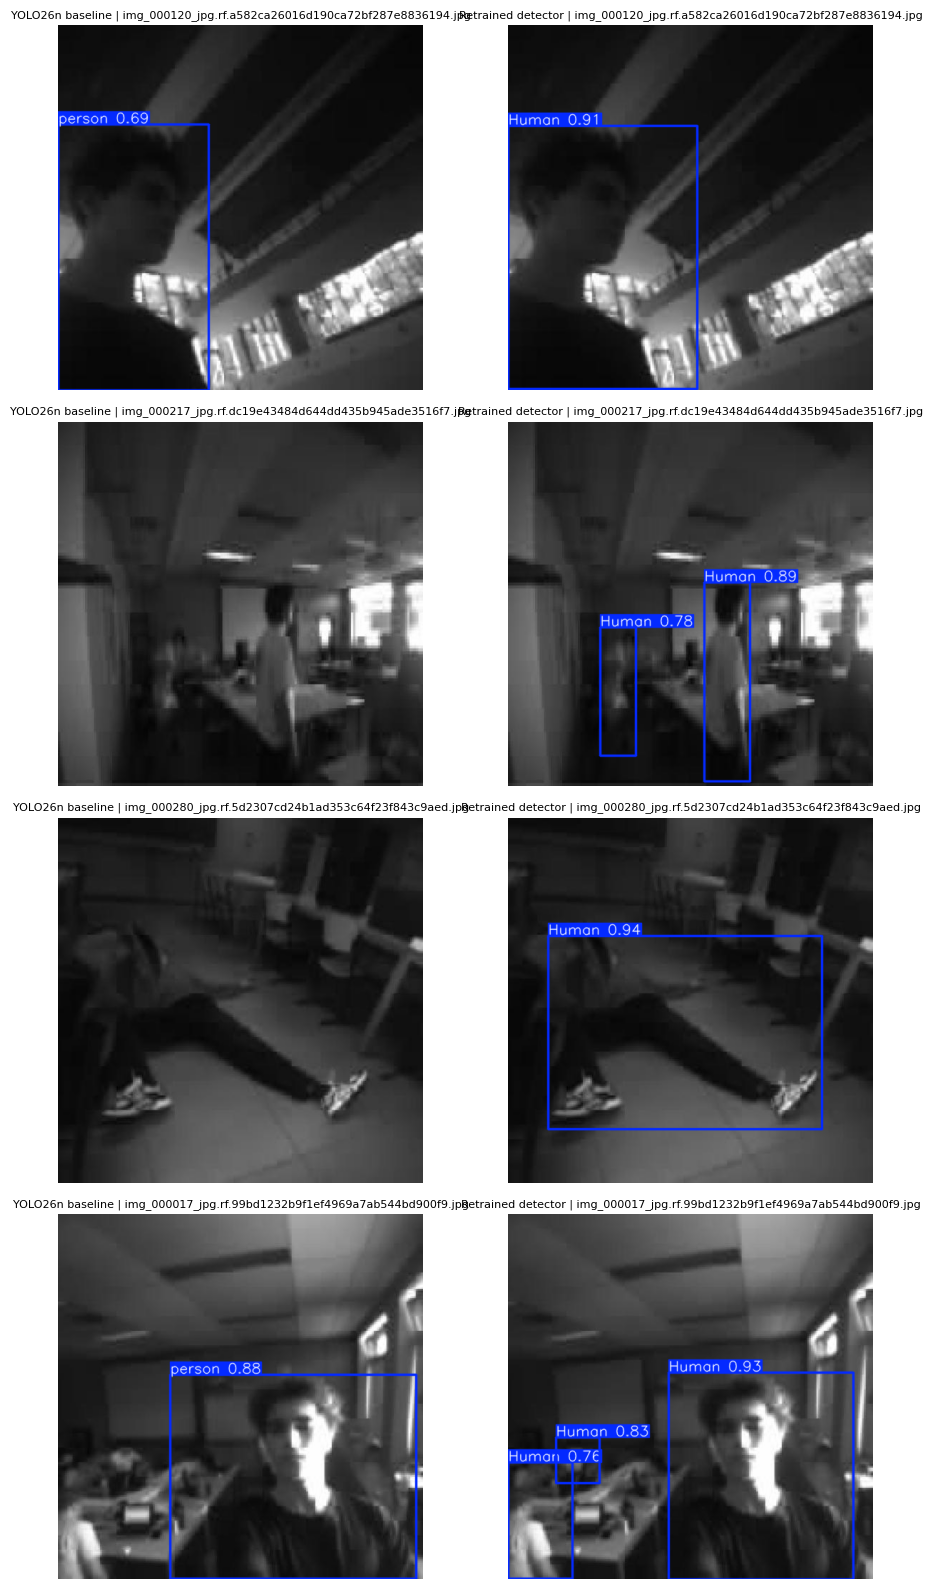

In [11]:
def draw_predictions(image_path: Path, model, title: str, imgsz: int, conf: float = 0.25):
    result = model.predict(
        source=str(image_path),
        imgsz=imgsz,
        conf=conf,
        device=TRAIN_DEVICE,
        verbose=False,
    )[0]
    plotted = result.plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    return plotted, title


baseline_model = YOLO("yolo26n.pt")
new_model = YOLO(str(best_weights))

sample_images = random.Random(SEED + 2).sample(test_images, k=min(4, len(test_images)))
fig, axes = plt.subplots(len(sample_images), 2, figsize=(10, 4 * len(sample_images)))
if len(sample_images) == 1:
    axes = [axes]

for row_axes, image_path in zip(axes, sample_images):
    base_plot, base_title = draw_predictions(image_path, baseline_model, "YOLO26n baseline", TRAIN_ARGS["imgsz"])
    new_plot, new_title = draw_predictions(image_path, new_model, "Retrained detector", TRAIN_ARGS["imgsz"])

    row_axes[0].imshow(base_plot)
    row_axes[0].set_title(f"{base_title} | {image_path.name}", fontsize=8)
    row_axes[0].axis("off")

    row_axes[1].imshow(new_plot)
    row_axes[1].set_title(f"{new_title} | {image_path.name}", fontsize=8)
    row_axes[1].axis("off")

plt.tight_layout()
